# Heart Disease Prediction with the Cleveland Dataset
### Problem Type

This is a **classification problem**, not a regression problem, because the target we want to predict is a category.  
After cleaning, the target becomes:

- `0` = no heart disease
- `1` = some level of heart disease present


## 1. Imports and setup
- We imported required libraries like NumPy, Pandas and sklearn.
- We configure the visualization settings.

In [7]:
from IPython.display import display
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = "data/processed.cleveland.data"
FIG_DIR = "data/heart_figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports loaded.")
print("Figure folder:", FIG_DIR)

Imports loaded.
Figure folder: data/heart_figures


## 2. Load the Cleveland `.data` file
- Loaded the dataset file from a local source.
- Assign column names to missing headers.
- Prints missing and placeholder values in the dataset

In [8]:
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=column_names,
    na_values="?"
)

# make the outcome binary
df["target"] = (df["target"] > 0).astype(int)

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nTarget counts:")
print(df["target"].value_counts().sort_index())
display(df.head())

Shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target counts:
target
0    164
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. First look at the data

I wanted to check two things first:

1. whether the classes are somewhat balanced  
2. whether the missing values are small enough to impute instead of dropping rows

The missing values only show up in `ca` and `thal`, so imputation makes sense here.

- We display the class balance and the summary stats for the dataset.

In [9]:
print("Class proportions:")
display((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

print("Summary stats:")
display(df.describe(include="all").T)

Class proportions:


target
0    54.13
1    45.87
Name: proportion, dtype: float64

Summary stats:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 4. Quick exploratory plots
- We used visualizations for exploring the data

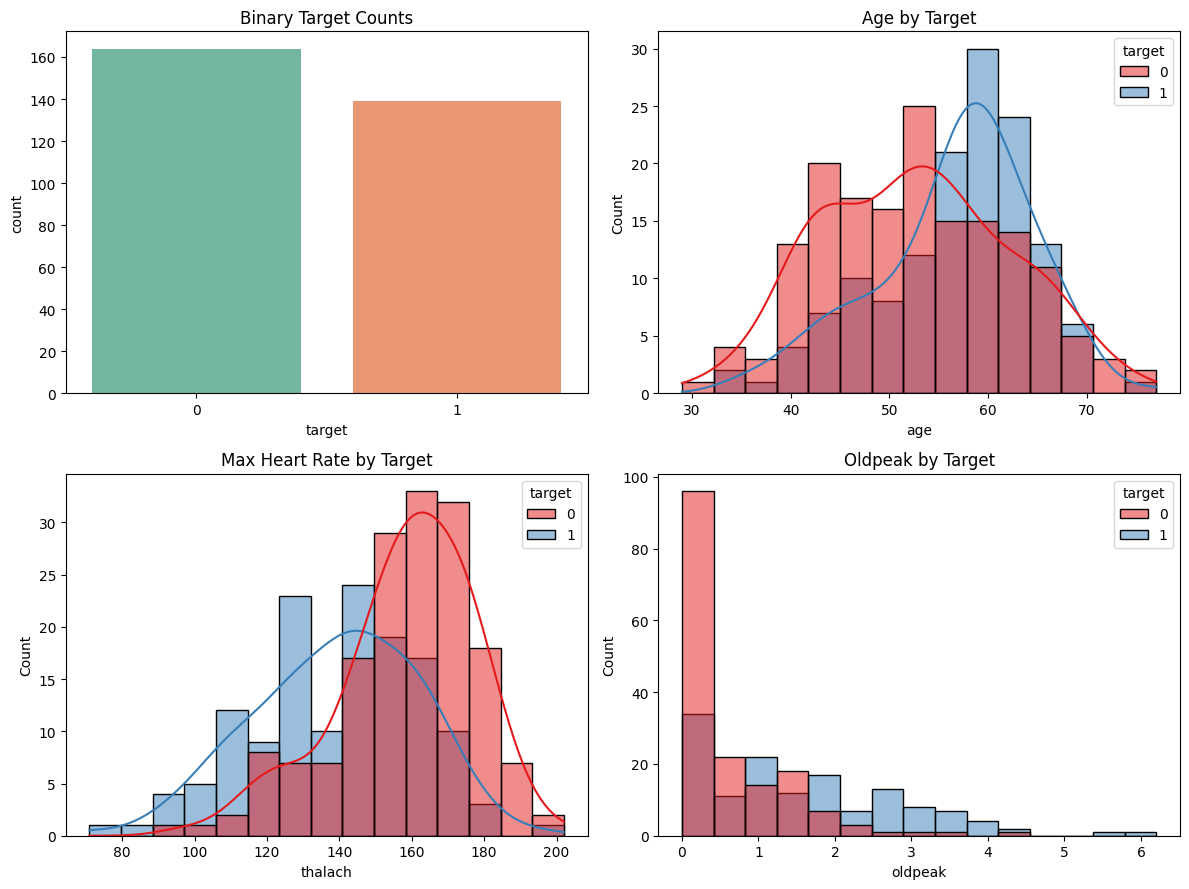

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=df, x="target", hue="target", ax=axes[0, 0], palette="Set2", legend=False)
axes[0, 0].set_title("Binary Target Counts")

sns.histplot(data=df, x="age", hue="target", bins=15, kde=True, ax=axes[0, 1], palette="Set1")
axes[0, 1].set_title("Age by Target")

sns.histplot(data=df, x="thalach", hue="target", bins=15, kde=True, ax=axes[1, 0], palette="Set1")
axes[1, 0].set_title("Max Heart Rate by Target")

sns.histplot(data=df, x="oldpeak", hue="target", bins=15, kde=False, ax=axes[1, 1], palette="Set1")
axes[1, 1].set_title("Oldpeak by Target")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eda_basic.png"), dpi=150, bbox_inches="tight")
plt.show()

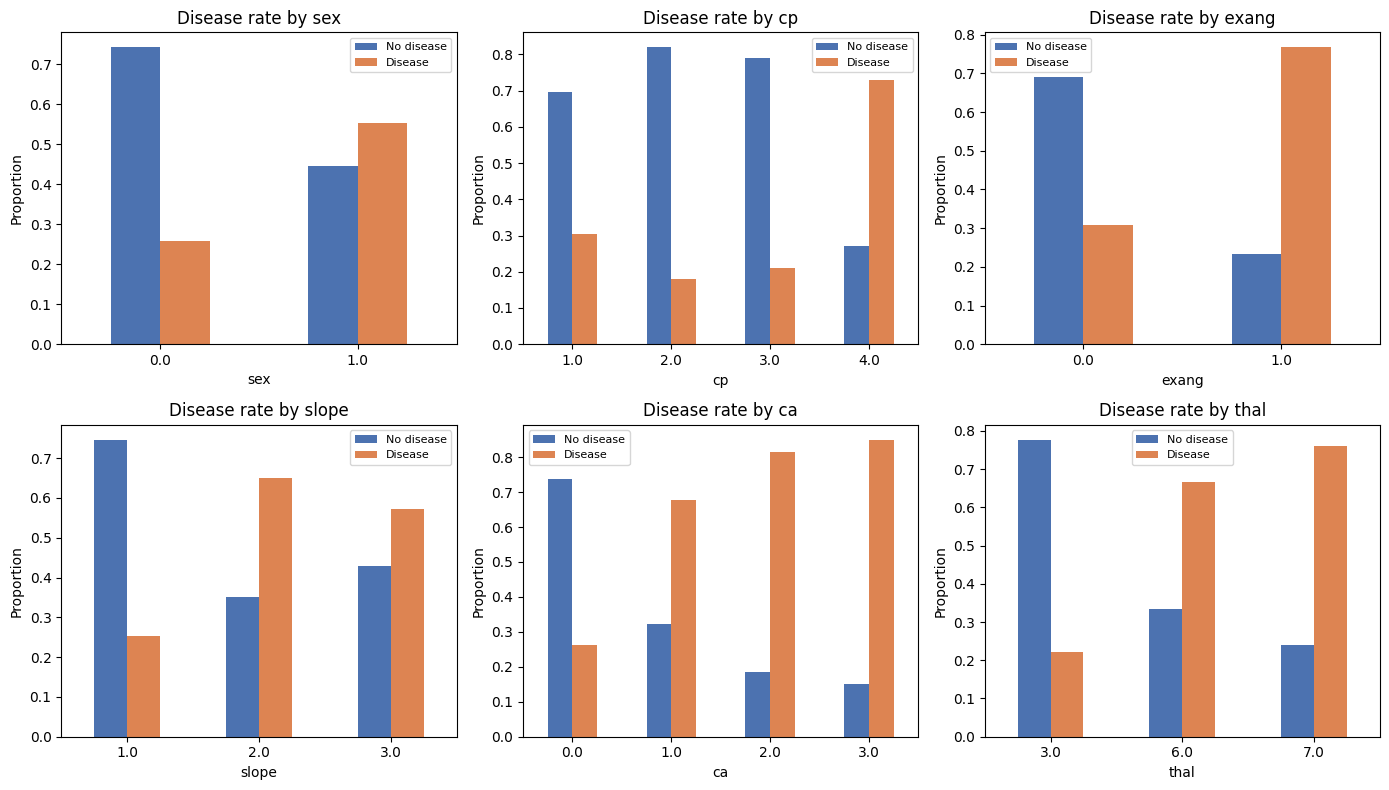

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

cat_preview = ["sex", "cp", "exang", "slope", "ca", "thal"]

for ax, col in zip(axes, cat_preview):
    tmp = pd.crosstab(df[col], df["target"], normalize="index")
    tmp.plot(kind="bar", stacked=False, ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"Disease rate by {col}")
    ax.set_ylabel("Proportion")
    ax.legend(["No disease", "Disease"], fontsize=8)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eda_categorical.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlation heatmap for numeric columns
- Calculated the correlation between the variables.
- Visualised it using a correlation heatmap.

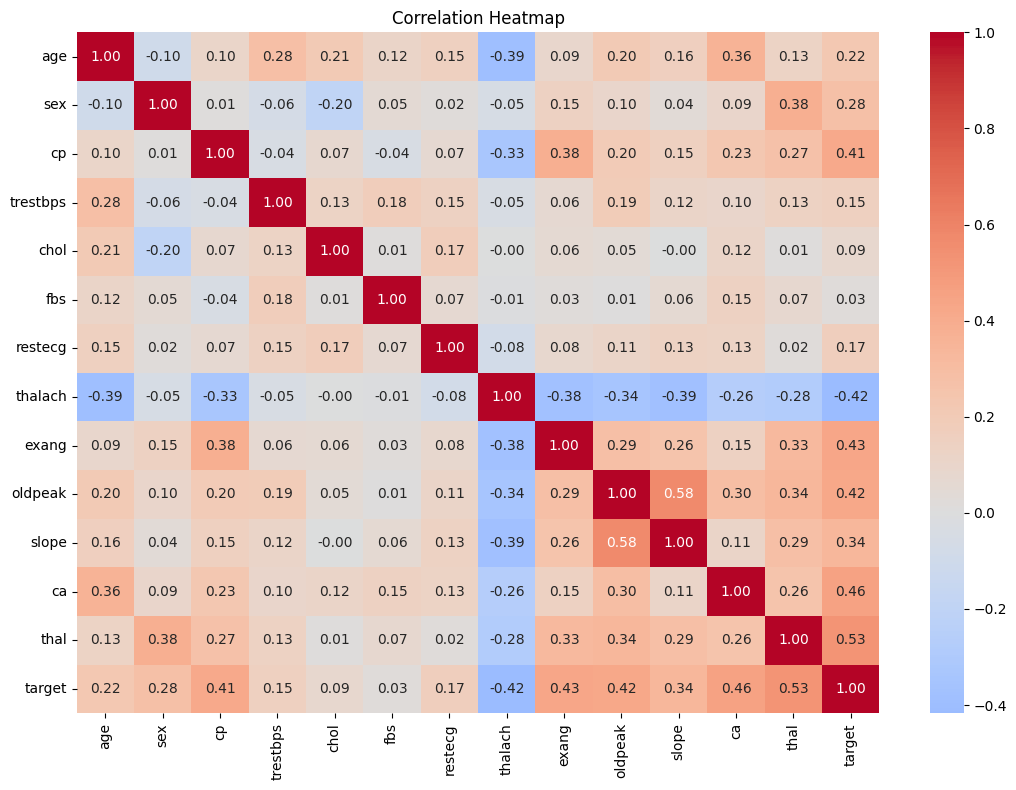

Top absolute correlations with target:


,abs_corr_with_target
thal,0.525689
ca,0.460442
exang,0.431894
oldpeak,0.424510
thalach,0.417167
cp,0.414446
slope,0.339213
sex,0.276816
age,0.223120
restecg,0.169202


In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Top absolute correlations with target:")
display(corr["target"].drop("target").abs().sort_values(ascending=False).to_frame("abs_corr_with_target"))

## 6. Feature setup

We decided to do a little bit of feature engineering, but not too much.  
Since this is a pretty small tabular medical dataset, we did not want to overcomplicate it.

we added:
- `age_thalach_ratio`: age compared to max heart rate achieved
- `oldpeak_exang_interaction`: a rough interaction between exercise-induced angina and ST depression

This is not guaranteed to help, but it is a reasonable experiment.

In [13]:
df_model = df.copy()

df_model["age_thalach_ratio"] = df_model["age"] / df_model["thalach"]
df_model["oldpeak_exang_interaction"] = df_model["oldpeak"] * (df_model["exang"] + 1)

X_df = df_model.drop(columns="target")
y = df_model["target"].astype(int).values

numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak",
    "age_thalach_ratio", "oldpeak_exang_interaction"
]

categorical_features = [c for c in X_df.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("\nCategorical/discrete features:", categorical_features)
print("\nX shape:", X_df.shape)
print("y shape:", y.shape)

Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_thalach_ratio', 'oldpeak_exang_interaction']

Categorical/discrete features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X shape: (303, 15)
y shape: (303,)


## 7. Preprocessing pipeline
- This applies scaling, encoding, and missing values.
- We used sklear pipelines for structured preprocessing.

In [14]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Preprocessor ready.")

Preprocessor ready.


## 8. Models

We kept the model set fairly realistic for this dataset:

- **Logistic Regression** for a strong baseline and interpretability
- **Random Forest** for nonlinear relationships
- **Gradient Boosting** because it often works well on small structured data
- **MLPClassifier** as a simple neural-network style comparison

We did **not** force LSTM or GRU into this version, because this dataset is not sequential data and the sample size is very small.  
That felt more honest than pretending the data had time steps when it really does not.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=4,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(32, 16),
        alpha=0.001,
        max_iter=600,
        random_state=42,
        early_stopping=True
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Models ready:", list(models.keys()))

Models ready: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'MLP']


## 9. Evaluation helper
- Created a function for model evaluation.
- Calculated metrics like accuracy, precision, recall and ROC-AUC.

In [16]:
def evaluate_model(name, estimator, X_df, y, cv):
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.zeros(len(y), dtype=float)

    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_df, y), start=1):
        X_train = X_df.iloc[train_idx].copy()
        X_valid = X_df.iloc[valid_idx].copy()
        y_train = y[train_idx]
        y_valid = y[valid_idx]

        pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", estimator)
        ])

        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_valid)
        proba = pipe.predict_proba(X_valid)[:, 1]

        oof_pred[valid_idx] = pred
        oof_proba[valid_idx] = proba

        fold_rows.append({
            "fold": fold,
            "accuracy": accuracy_score(y_valid, pred),
            "precision": precision_score(y_valid, pred, zero_division=0),
            "recall": recall_score(y_valid, pred, zero_division=0),
            "f1": f1_score(y_valid, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, proba)
        })

    elapsed = time.time() - start
    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df.mean(numeric_only=True).to_dict()
    summary_std = fold_df.std(numeric_only=True).to_dict()

    return {
        "fold_df": fold_df,
        "summary": summary,
        "summary_std": summary_std,
        "oof_pred": oof_pred,
        "oof_proba": oof_proba,
        "time_sec": elapsed
    }

print("Helper built.")

Helper built.


## 10. Run cross-validation
- This applies k fold cross validation to the models.

In [17]:
results = {}

for name, model in models.items():
    print("\n" + "=" * 60)
    print("Running:", name)
    out = evaluate_model(name, model, X_df, y, cv)
    results[name] = out

    print("Time (s):", round(out["time_sec"], 3))
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        m = out["summary"][metric]
        s = out["summary_std"][metric]
        print(f"{metric:10s}: {m:.4f} ± {s:.4f}")


Running: Logistic Regression
Time (s): 0.044
accuracy  : 0.8547 ± 0.0431
precision : 0.8936 ± 0.0568
recall    : 0.7762 ± 0.0686
f1        : 0.8296 ± 0.0550
roc_auc   : 0.9163 ± 0.0193

Running: Random Forest
Time (s): 0.467
accuracy  : 0.8383 ± 0.0214
precision : 0.8478 ± 0.0391
recall    : 0.7910 ± 0.0488
f1        : 0.8173 ± 0.0282
roc_auc   : 0.9173 ± 0.0174

Running: Gradient Boosting
Time (s): 0.306
accuracy  : 0.8085 ± 0.0352
precision : 0.8056 ± 0.0494
recall    : 0.7690 ± 0.0644
f1        : 0.7856 ± 0.0458
roc_auc   : 0.8926 ± 0.0120

Running: MLP
Time (s): 0.084
accuracy  : 0.6735 ± 0.0771
precision : 0.6315 ± 0.3700
recall    : 0.4185 ± 0.2414
f1        : 0.4957 ± 0.2773
roc_auc   : 0.7355 ± 0.2181


## 11. Overall results table
- This shows all the results of modele training in one.
- Compares model side-by-side.

In [18]:
rows = []
for name, out in results.items():
    rows.append({
        "Model": name,
        "Accuracy": f"{out['summary']['accuracy']:.4f} ± {out['summary_std']['accuracy']:.4f}",
        "Precision": f"{out['summary']['precision']:.4f} ± {out['summary_std']['precision']:.4f}",
        "Recall": f"{out['summary']['recall']:.4f} ± {out['summary_std']['recall']:.4f}",
        "F1": f"{out['summary']['f1']:.4f} ± {out['summary_std']['f1']:.4f}",
        "ROC-AUC": f"{out['summary']['roc_auc']:.4f} ± {out['summary_std']['roc_auc']:.4f}",
        "Time (s)": round(out["time_sec"], 3)
    })

results_table = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
display(results_table)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Time (s)
1,Random Forest,0.8383 ± 0.0214,0.8478 ± 0.0391,0.7910 ± 0.0488,0.8173 ± 0.0282,0.9173 ± 0.0174,0.467
0,Logistic Regression,0.8547 ± 0.0431,0.8936 ± 0.0568,0.7762 ± 0.0686,0.8296 ± 0.0550,0.9163 ± 0.0193,0.044
2,Gradient Boosting,0.8085 ± 0.0352,0.8056 ± 0.0494,0.7690 ± 0.0644,0.7856 ± 0.0458,0.8926 ± 0.0120,0.306
3,MLP,0.6735 ± 0.0771,0.6315 ± 0.3700,0.4185 ± 0.2414,0.4957 ± 0.2773,0.7355 ± 0.2181,0.084


## 12. ROC curves using out-of-fold probabilities
- This section plots the ROC AUC curve for each model.
- compares models using AUC scores.

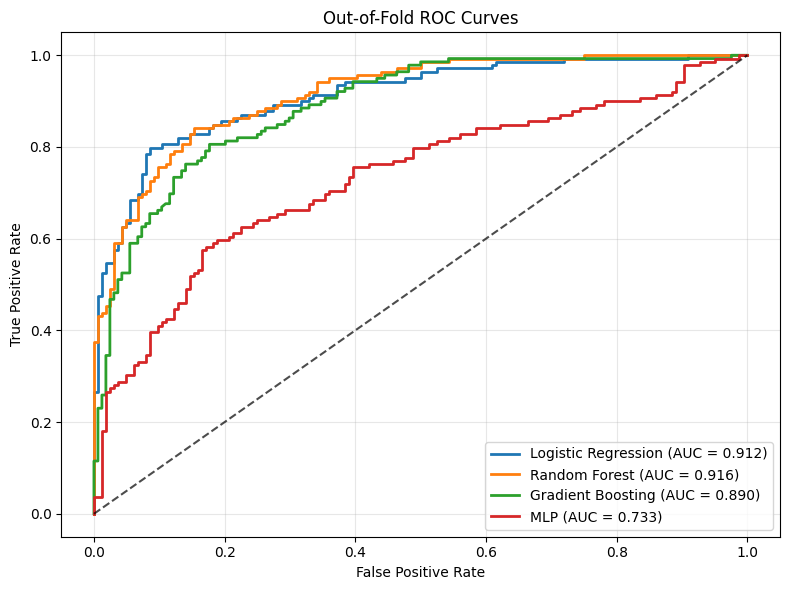

In [19]:
plt.figure(figsize=(8, 6))

for name, out in results.items():
    fpr, tpr, _ = roc_curve(y, out["oof_proba"])
    auc_val = roc_auc_score(y, out["oof_proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-Fold ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "oof_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion matrices

These are based on **out-of-fold predictions**, which is better than fitting on the full dataset and then scoring on the same data.
- Displayes the confusion matrices for prediction.
- Shows classification errors.

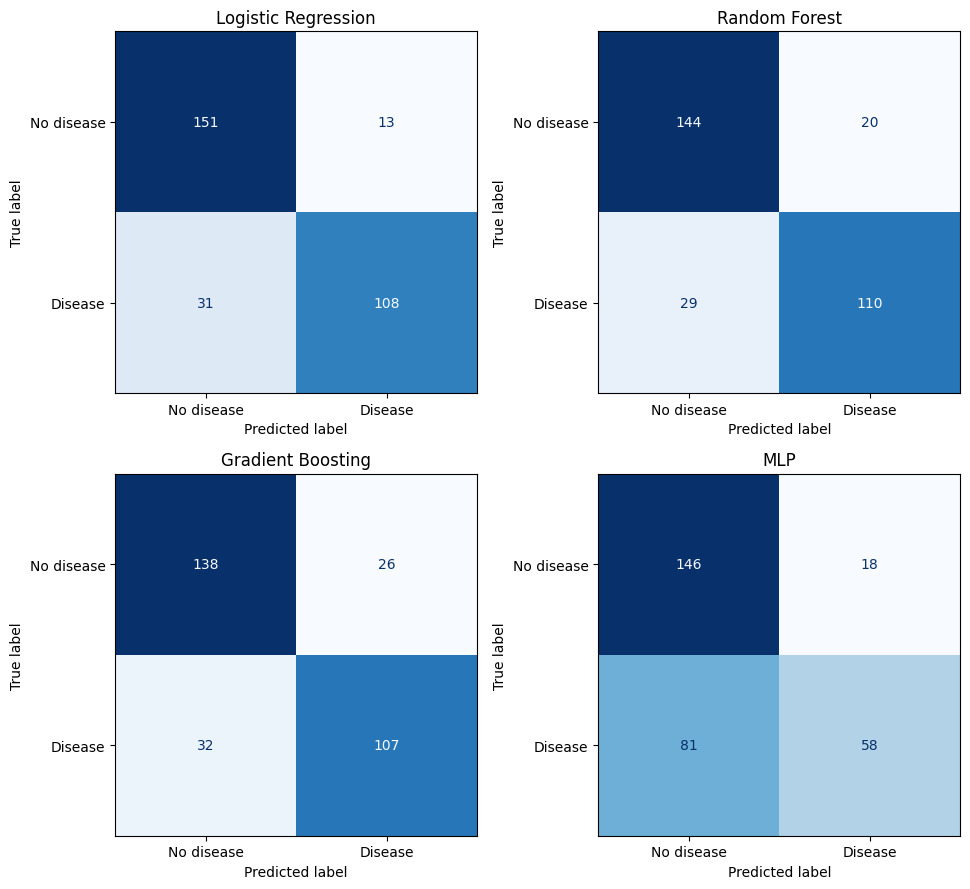

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, (name, out) in zip(axes, results.items()):
    cm = confusion_matrix(y, out["oof_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "oof_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Feature importance / model interpretation

For interpretation, we looked at two different things:

- Logistic regression coefficient magnitudes
- Random forest permutation importance

This is not perfect because the models explain importance differently, but it still gives a useful picture.

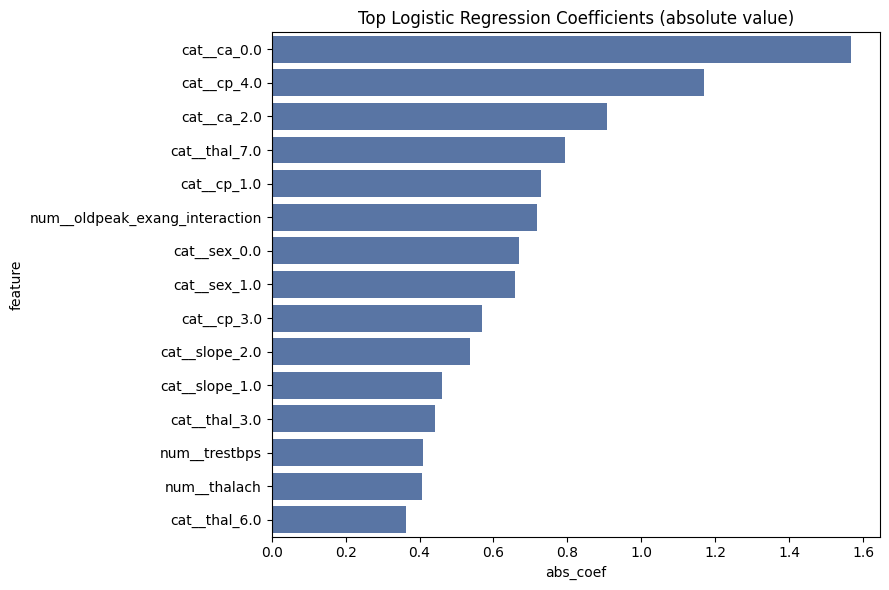

,feature,abs_coef
23,cat__ca_0.0,1.567267
12,cat__cp_4.0,1.169520
25,cat__ca_2.0,0.908223
29,cat__thal_7.0,0.793726
9,cat__cp_1.0,0.728108
6,num__oldpeak_exang_interaction,0.716639
7,cat__sex_0.0,0.670366
8,cat__sex_1.0,0.659597
11,cat__cp_3.0,0.569071
21,cat__slope_2.0,0.537205


In [22]:
log_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", models["Logistic Regression"])
])
log_pipe.fit(X_df, y)

feature_names_after_prep = log_pipe.named_steps["prep"].get_feature_names_out()
coef_vals = np.abs(log_pipe.named_steps["model"].coef_[0])

coef_df = pd.DataFrame({
    "feature": feature_names_after_prep,
    "abs_coef": coef_vals
}).sort_values("abs_coef", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=coef_df, y="feature", x="abs_coef", color="#4C72B0")
plt.title("Top Logistic Regression Coefficients (absolute value)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "logistic_coefficients.png"), dpi=150, bbox_inches="tight")
plt.show()

display(coef_df)

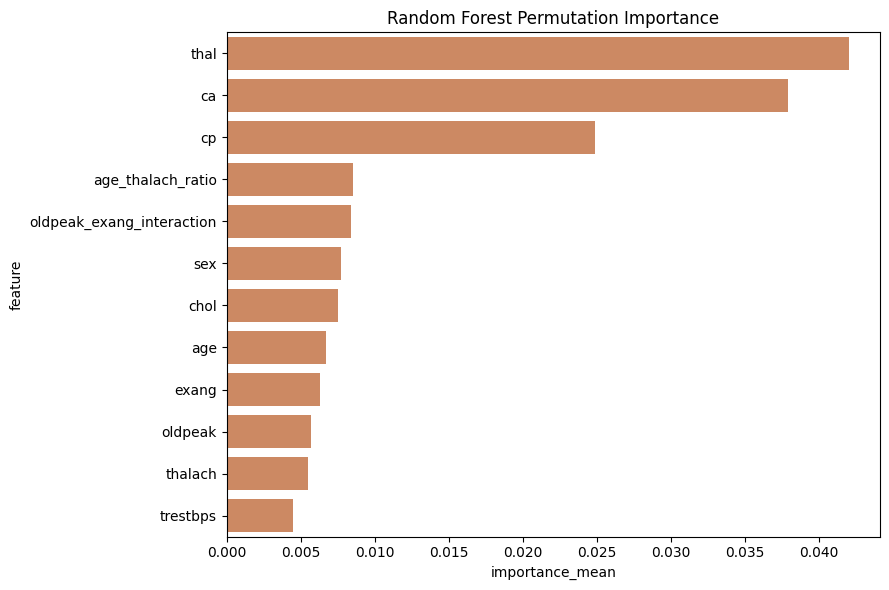

,feature,importance_mean,importance_std
12,thal,0.042005,0.004690
11,ca,0.037904,0.004537
2,cp,0.024838,0.004934
13,age_thalach_ratio,0.008499,0.001986
14,oldpeak_exang_interaction,0.008414,0.002989
1,sex,0.007743,0.002707
4,chol,0.007497,0.000887
0,age,0.006685,0.000806
8,exang,0.006297,0.002361
9,oldpeak,0.005672,0.001794


In [23]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", models["Random Forest"])
])
rf_pipe.fit(X_df, y)

perm = permutation_importance(
    rf_pipe, X_df, y,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_df.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).head(12)

plt.figure(figsize=(9, 6))
sns.barplot(data=perm_df, y="feature", x="importance_mean", color="#DD8452")
plt.title("Random Forest Permutation Importance")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rf_permutation_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

display(perm_df)

## 15. Simple model comparison by performance and usability

In [24]:
comparison_rows = []
interpretability = {
    "Logistic Regression": "High",
    "Random Forest": "Medium",
    "Gradient Boosting": "Medium",
    "MLP": "Low"
}

for name, out in results.items():
    comparison_rows.append({
        "Model": name,
        "ROC_AUC_mean": round(out["summary"]["roc_auc"], 4),
        "F1_mean": round(out["summary"]["f1"], 4),
        "Time_sec": round(out["time_sec"], 3),
        "Interpretability": interpretability[name]
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("ROC_AUC_mean", ascending=False)
display(comparison_df)

comparison_df.to_csv("data/heart_model_comparison.csv", index=False)
print("Saved: data/heart_model_comparison.csv")

,Model,ROC_AUC_mean,F1_mean,Time_sec,Interpretability
1,Random Forest,0.9173,0.8173,0.467,Medium
0,Logistic Regression,0.9163,0.8296,0.044,High
2,Gradient Boosting,0.8926,0.7856,0.306,Medium
3,MLP,0.7355,0.4957,0.084,Low


Saved: data/heart_model_comparison.csv


## 16. LSTM

In [25]:
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam


def evaluate_rnn_model(name, model_type, X_df, y, cv, preprocessor):
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.zeros(len(y), dtype=float)

    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_df, y), start=1):
        X_train = X_df.iloc[train_idx].copy()
        X_valid = X_df.iloc[valid_idx].copy()
        y_train = np.array(y)[train_idx]
        y_valid = np.array(y)[valid_idx]

        # Fit preprocessing on training fold only
        X_train_processed = preprocessor.fit_transform(X_train)
        X_valid_processed = preprocessor.transform(X_valid)

        # Convert to numpy arrays
        X_train_processed = np.array(X_train_processed)
        X_valid_processed = np.array(X_valid_processed)

        # Reshape for LSTM/GRU: (samples, time_steps, features)
        # For tabular data, we use 1 time step
        X_train_rnn = X_train_processed.reshape(X_train_processed.shape[0], 1, X_train_processed.shape[1])
        X_valid_rnn = X_valid_processed.reshape(X_valid_processed.shape[0], 1, X_valid_processed.shape[1])

        # Build model
        model = Sequential()

        if model_type == "LSTM":
            model.add(LSTM(32, input_shape=(1, X_train_processed.shape[1])))
        elif model_type == "GRU":
            model.add(GRU(32, input_shape=(1, X_train_processed.shape[1])))

        model.add(Dropout(0.2))
        model.add(Dense(1, activation="sigmoid"))

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        # Train model
        model.fit(
            X_train_rnn,
            y_train,
            epochs=20,
            batch_size=16,
            verbose=0
        )

        # Predict probabilities and classes
        proba = model.predict(X_valid_rnn, verbose=0).ravel()
        pred = (proba >= 0.5).astype(int)

        oof_pred[valid_idx] = pred
        oof_proba[valid_idx] = proba

        fold_rows.append({
            "fold": fold,
            "accuracy": accuracy_score(y_valid, pred),
            "precision": precision_score(y_valid, pred, zero_division=0),
            "recall": recall_score(y_valid, pred, zero_division=0),
            "f1": f1_score(y_valid, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, proba)
        })

        print(f"{name} | Fold {fold} complete")

    elapsed = time.time() - start
    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df.mean(numeric_only=True).to_dict()
    summary_std = fold_df.std(numeric_only=True).to_dict()

    return {
        "fold_df": fold_df,
        "summary": summary,
        "summary_std": summary_std,
        "oof_pred": oof_pred,
        "oof_proba": oof_proba,
        "time_sec": elapsed
    }

In [26]:
# Run LSTM
lstm_results = evaluate_rnn_model(
    name="LSTM",
    model_type="LSTM",
    X_df=X_df,
    y=y,
    cv=cv,
    preprocessor=preprocessor
)

print("\nLSTM Fold Results")
print(lstm_results["fold_df"])

print("\nLSTM Summary")
print(lstm_results["summary"])

LSTM | Fold 1 complete
LSTM | Fold 2 complete
LSTM | Fold 3 complete
LSTM | Fold 4 complete
LSTM | Fold 5 complete

LSTM Fold Results
   fold  accuracy  precision    recall        f1   roc_auc
0     1  0.934426   0.900000  0.964286  0.931034  0.951299
1     2  0.803279   0.833333  0.714286  0.769231  0.887446
2     3  0.852459   0.827586  0.857143  0.842105  0.917749
3     4  0.800000   0.826087  0.703704  0.760000  0.897868
4     5  0.883333   0.956522  0.785714  0.862745  0.938616

LSTM Summary
{'fold': 3.0, 'accuracy': 0.8546994535519126, 'precision': 0.8687056471764117, 'recall': 0.8050264550264551, 'f1': 0.8330231226373002, 'roc_auc': 0.9185954284912619}


## 17. GRU

In [27]:
# Run GRU
gru_results = evaluate_rnn_model(
    name="GRU",
    model_type="GRU",
    X_df=X_df,
    y=y,
    cv=cv,
    preprocessor=preprocessor
)

print("\nGRU Fold Results")
print(gru_results["fold_df"])

print("\nGRU Summary")
print(gru_results["summary"])

GRU | Fold 1 complete
GRU | Fold 2 complete
GRU | Fold 3 complete
GRU | Fold 4 complete
GRU | Fold 5 complete

GRU Fold Results
   fold  accuracy  precision    recall        f1   roc_auc
0     1  0.901639   0.866667  0.928571  0.896552  0.953463
1     2  0.836066   0.846154  0.785714  0.814815  0.879870
2     3  0.852459   0.880000  0.785714  0.830189  0.908009
3     4  0.800000   0.800000  0.740741  0.769231  0.906846
4     5  0.866667   0.916667  0.785714  0.846154  0.937500

GRU Summary
{'fold': 3.0, 'accuracy': 0.8513661202185794, 'precision': 0.861897435897436, 'recall': 0.8052910052910052, 'f1': 0.8313879667165288, 'roc_auc': 0.9171376463043132}
